In [3]:
# Necessary Imports
from bmfm_sm.api.smmv_api import SmallMoleculeMultiViewModel, PredictionIterator
from bmfm_sm.core.data_modules.namespace import LateFusionStrategy
from bmfm_sm.api.dataset_registry import DatasetRegistry

#imports for new BiomedMultiViewEncoder class
from bmfm_sm.predictive.data_modules.image_finetune_dataset import ImageFinetuneDataPipeline
from bmfm_sm.predictive.data_modules.text_finetune_dataset import TextFinetuneDataPipeline
from bmfm_sm.predictive.data_modules.graph_finetune_dataset import Graph2dFinetuneDataPipeline

from dataclasses import asdict
from itertools import islice
import pandas as pd
import os
import torch
import torch.nn as nn

#imports for visualization
import numpy as np
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
import seaborn as sns

/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/torch_geometric/typing.py:18: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: dlopen(/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/libpyg.so, 0x0006): tried: '/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/libpyg.so' (mach-o file, but is an incompatible architecture (have 'x86_64', need 'arm64e' or 'arm64')), '/System/Volumes/Preboot/Cryptexes/OS/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/libpyg.so' (no such file), '/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/libpyg.so' (mach-o file, but is an incompatible architecture (have 'x86_64', need 'arm64e' or 'arm64'))
  warnings.warn(f"An issue occurred

In [4]:
from torch.nn.functional import pad
from torch.nn.utils.rnn import pad_sequence

class BiomedMultiViewEncoder(nn.Module):
    def __init__(
        self
    ):
        super(BiomedMultiViewEncoder, self).__init__()
        # Initialize the pretrained model
        biomed_smmv_pretrained = SmallMoleculeMultiViewModel.from_pretrained(
            LateFusionStrategy.ATTENTIONAL,
            #model_path='../data_root/bmfm_model_dir/pretrained/MULTIVIEW_MODEL/biomed-smmv-with-coeff-agg.pth',
            inference_mode=False,
        )
        # Initialize the model subcomponents
        self.model_graph = biomed_smmv_pretrained.model_graph # output dim: 512
        self.model_image = biomed_smmv_pretrained.model_image # output dim: 512
        self.model_text = biomed_smmv_pretrained.model_text   # output dim: 768

    # Helper function for collating the individual processed graph samples:
    @staticmethod
    def collate_graph_data(graph_data_list):
        collated = {}
        collated["node_num"] = torch.cat([sample['node_num'] for sample in graph_data_list])
        collated["node_data"] = torch.cat([sample['node_data'] for sample in graph_data_list])
        collated["edge_num"] = torch.cat([sample['edge_num'] for sample in graph_data_list])
        collated["edge_data"] = torch.cat([sample['edge_data'] for sample in graph_data_list])
        collated["edge_index"] = torch.cat([sample['edge_index'] for sample in graph_data_list], dim=1)

        max_node_num = max(collated["node_num"])
        collated["lap_eigvec"] = torch.cat(
                [
                    pad(i, (0, max_node_num - i.size(1)), value=float("0"))
                    for i in [sample["lap_eigvec"] for sample in graph_data_list]
                ]
            )
        return collated

    def forward(self, smiles: list):
        tokenized_smiles_list = []
        attention_mask_list = []
        graph_data_list = []
        
        image_tensors = []
        graph_emb = []

        for sm in smiles:
            # Prepare image and text data in batch format
            img_data = ImageFinetuneDataPipeline.smiles_to_image_format(sm)
            image_tensors.append(img_data['img'].squeeze(0)) # Remove extra batch dimension if present

            txt_data = TextFinetuneDataPipeline.smiles_to_text_format(sm)
            tokenized_smiles_list.append(txt_data['smiles.tokenized'].squeeze(0))
            attention_mask_list.append(txt_data['attention_mask'].squeeze(0))

            # Run the graph model on individual smiles
            graph_data = Graph2dFinetuneDataPipeline.smiles_to_graph_format(sm)
            graph_data_list.append(graph_data)
            #graph_emb.append(self.model_graph(graph_data).squeeze(0))

        # Run the image and text models on the batched data
        image_batch = torch.stack(image_tensors, dim=0) #.to(device)
        tokenized_smiles_batch = pad_sequence(tokenized_smiles_list, batch_first=True) #.to(device)
        attention_mask_batch = pad_sequence(attention_mask_list, batch_first=True) #.to(device)
        graph_batch = BiomedMultiViewEncoder.collate_graph_data(graph_data_list)
        
        image_emb = self.model_image(image_batch)
        text_emb = self.model_text(tokenized_smiles_batch, attention_mask_batch)
        graph_emb = self.model_graph(graph_batch)

        return [graph_emb, image_emb, text_emb]

In [3]:
os.environ['BMFM_HOME'] = '/Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/data_root/package_tiny'

def get_all_mmp_smiles(datasets=['mmp_ac_s_distinct', 'mmp_ac_s_neg_distinct']):
        
    smiles_dict = {}
    for dataset in datasets:
        try:
            # Build file path using lower-case version of the dataset name
            csv_filename = f"{dataset}.csv"
            csv_path = f"/Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/notebooks/{csv_filename}"
            df = pd.read_csv(csv_path)
            df = df[0:20000]
            
            smiles_col_1 = df.columns[0] 
            smiles_dict[dataset + '_item_1'] = df[smiles_col_1].tolist()
            smiles_col_2 = df.columns[2] 
            smiles_dict[dataset + '_item_2'] = df[smiles_col_2].tolist()
            
            print(f"{dataset}: {len(smiles_dict[dataset])} SMILES found.")
            
        except Exception as e:
            print(f"Error processing dataset {dataset}: {str(e)}")
            continue

    return smiles_dict

# Retrieve SMILES for specific datasets (e.g., ESOL and LIPOPHILICITY)

smiles_dict = get_all_mmp_smiles()

# Initialize the encoder
encoder = BiomedMultiViewEncoder()

# Define batch size for processing
batch_size = 10

# Process each dataset separately to generate and save embeddings
for dataset_name, smiles_list in smiles_dict.items():
    # If you used append() and the list is nested, flatten it:
    if smiles_list and isinstance(smiles_list[0], list):
        smiles_list = smiles_list[0]
    
    print(f"\nProcessing dataset: {dataset_name} with {len(smiles_list)} SMILES")
    
    graph_batches = []
    image_batches = []
    text_batches = []
    
    # Process in batches
    for i in range(0, len(smiles_list), batch_size):
        batch_smiles = smiles_list[i:i+batch_size]
        try:
            outputs = encoder(batch_smiles)
            graph_batches.append(outputs[0].detach().cpu().numpy())
            image_batches.append(outputs[1].detach().cpu().numpy())
            text_batches.append(outputs[2].detach().cpu().numpy())
            
            print(f"  Processed batch {i // batch_size + 1} of {((len(smiles_list)-1)//batch_size)+1}")
        except Exception as e:
            print(f"Error encoding batch starting at index {i} in {dataset_name}: {e}")
    
    # Concatenate embeddings for each modality if available
    if graph_batches:
        graph_embeddings = np.concatenate(graph_batches, axis=0)
        image_embeddings = np.concatenate(image_batches, axis=0)
        text_embeddings = np.concatenate(text_batches, axis=0)
        
        # Save embeddings to separate files for each dataset
        np.save(f'graph_embeddings_{dataset_name.lower()}.npy', graph_embeddings)
        np.save(f'image_embeddings_{dataset_name.lower()}.npy', image_embeddings)
        np.save(f'text_embeddings_{dataset_name.lower()}.npy', text_embeddings)
        
        print(f"Embeddings for {dataset_name} saved successfully.")
    else:
        print(f"No embeddings produced for dataset {dataset_name}.")


Error processing dataset mmp_ac_s_distinct: 'mmp_ac_s_distinct'
Error processing dataset mmp_ac_s_neg_distinct: 'mmp_ac_s_neg_distinct'


/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
2025-03-18 18:06:10,826 - root - INFO - MWPF4XZSD2.yu.yale.edu:8575305792:0:0 - Using coeff_mlp architecture for aggregator
2025-03-18 18:06:10,827 - root - INFO - MWPF4XZSD2.yu.yale.edu:8575305792:0:0 - dim_list [512, 512, 768] for aggregator
2025-03-18 18:06:10,836 - root - INFO - MWPF4XZSD2.yu.yale.edu:8575305792:0:0 - Loading checkpoint from default p


Processing dataset: mmp_ac_s_distinct_item_1 with 20000 SMILES


/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/fast_transformers/feature_maps/fourier_features.py:37: UserWarning: torch.qr is deprecated in favor of torch.linalg.qr and will be removed in a future PyTorch release.
The boolean parameter 'some' has been replaced with a string parameter 'mode'.
Q, R = torch.qr(A, some)
should be replaced with
Q, R = torch.linalg.qr(A, 'reduced' if some else 'complete') (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2432.)
  Q, _ = torch.qr(block)


  Processed batch 1 of 2000
  Processed batch 2 of 2000
  Processed batch 3 of 2000
  Processed batch 4 of 2000
  Processed batch 5 of 2000
  Processed batch 6 of 2000
  Processed batch 7 of 2000
  Processed batch 8 of 2000
  Processed batch 9 of 2000
  Processed batch 10 of 2000
  Processed batch 11 of 2000
  Processed batch 12 of 2000
  Processed batch 13 of 2000
  Processed batch 14 of 2000
  Processed batch 15 of 2000
  Processed batch 16 of 2000
  Processed batch 17 of 2000
  Processed batch 18 of 2000
  Processed batch 19 of 2000
  Processed batch 20 of 2000
  Processed batch 21 of 2000
  Processed batch 22 of 2000
  Processed batch 23 of 2000
  Processed batch 24 of 2000
  Processed batch 25 of 2000
  Processed batch 26 of 2000
  Processed batch 27 of 2000
  Processed batch 28 of 2000
  Processed batch 29 of 2000
  Processed batch 30 of 2000
  Processed batch 31 of 2000
  Processed batch 32 of 2000
  Processed batch 33 of 2000
  Processed batch 34 of 2000
  Processed batch 35 of


Analyzing dataset: mmp_ac_s_distinct


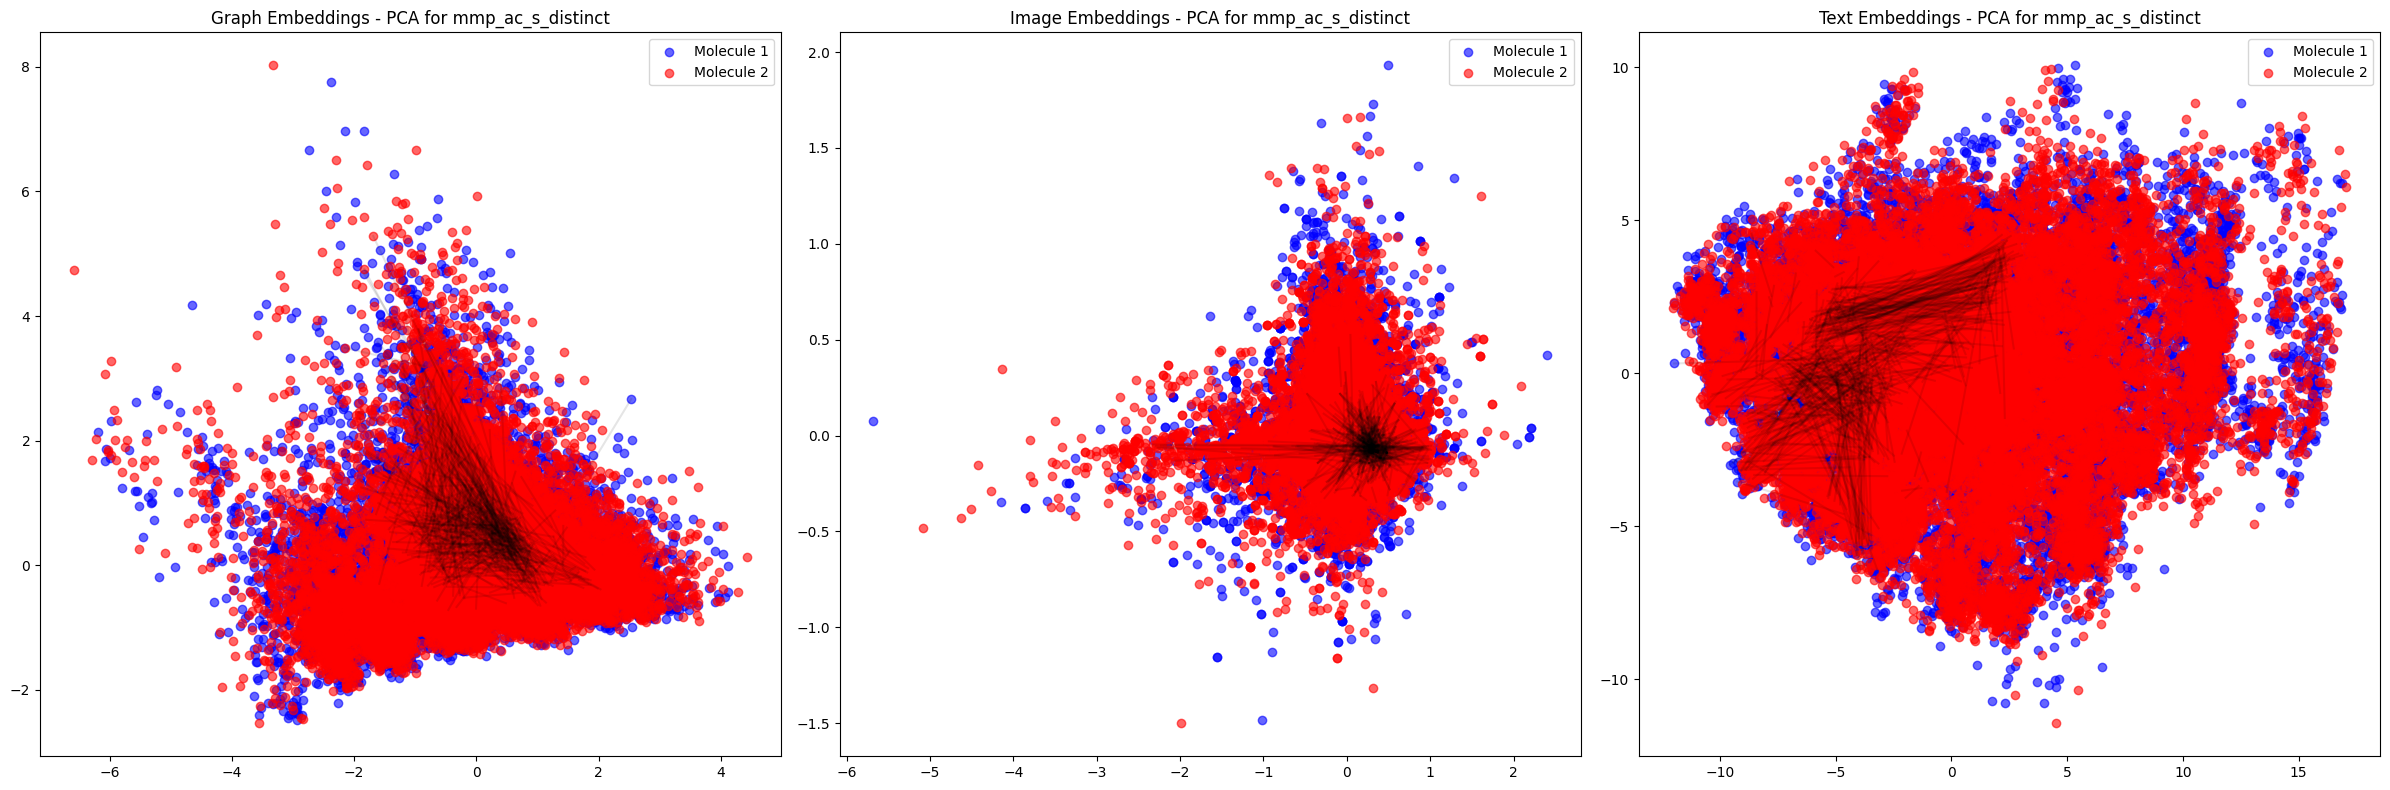

/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/umap/spectral.py:550: UserWarning: S

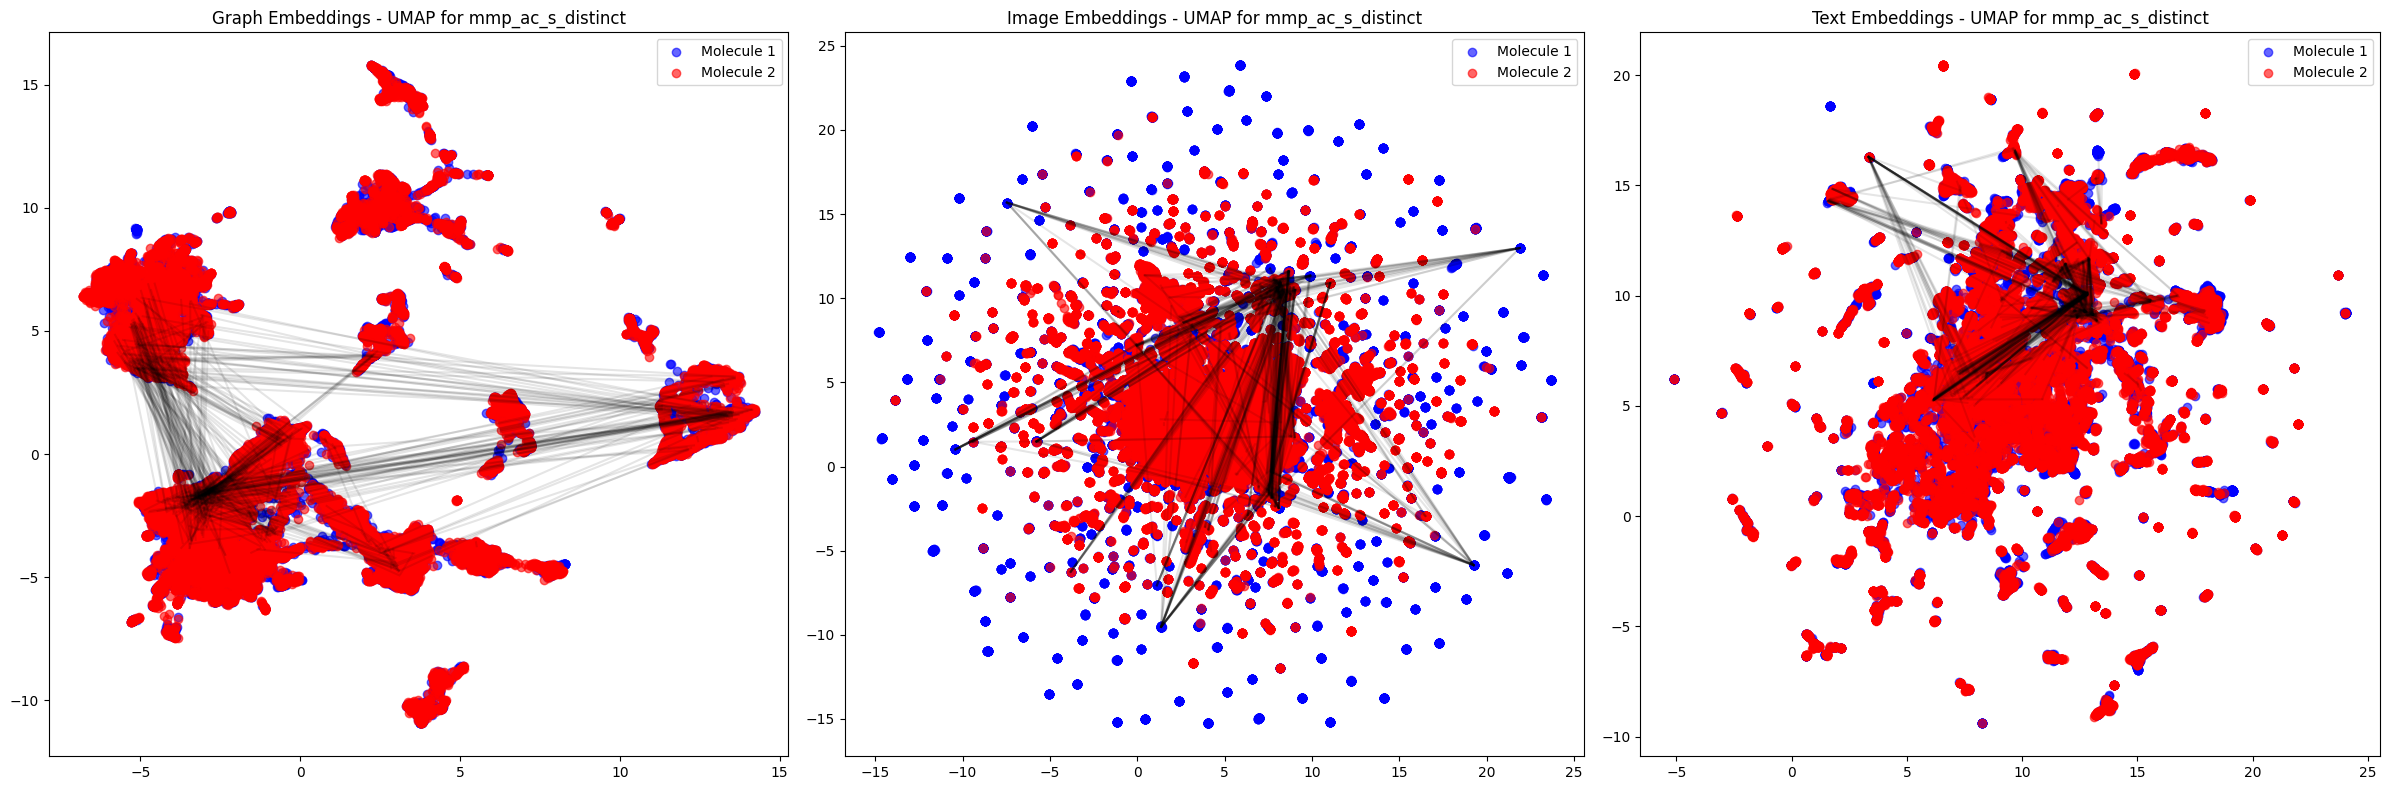

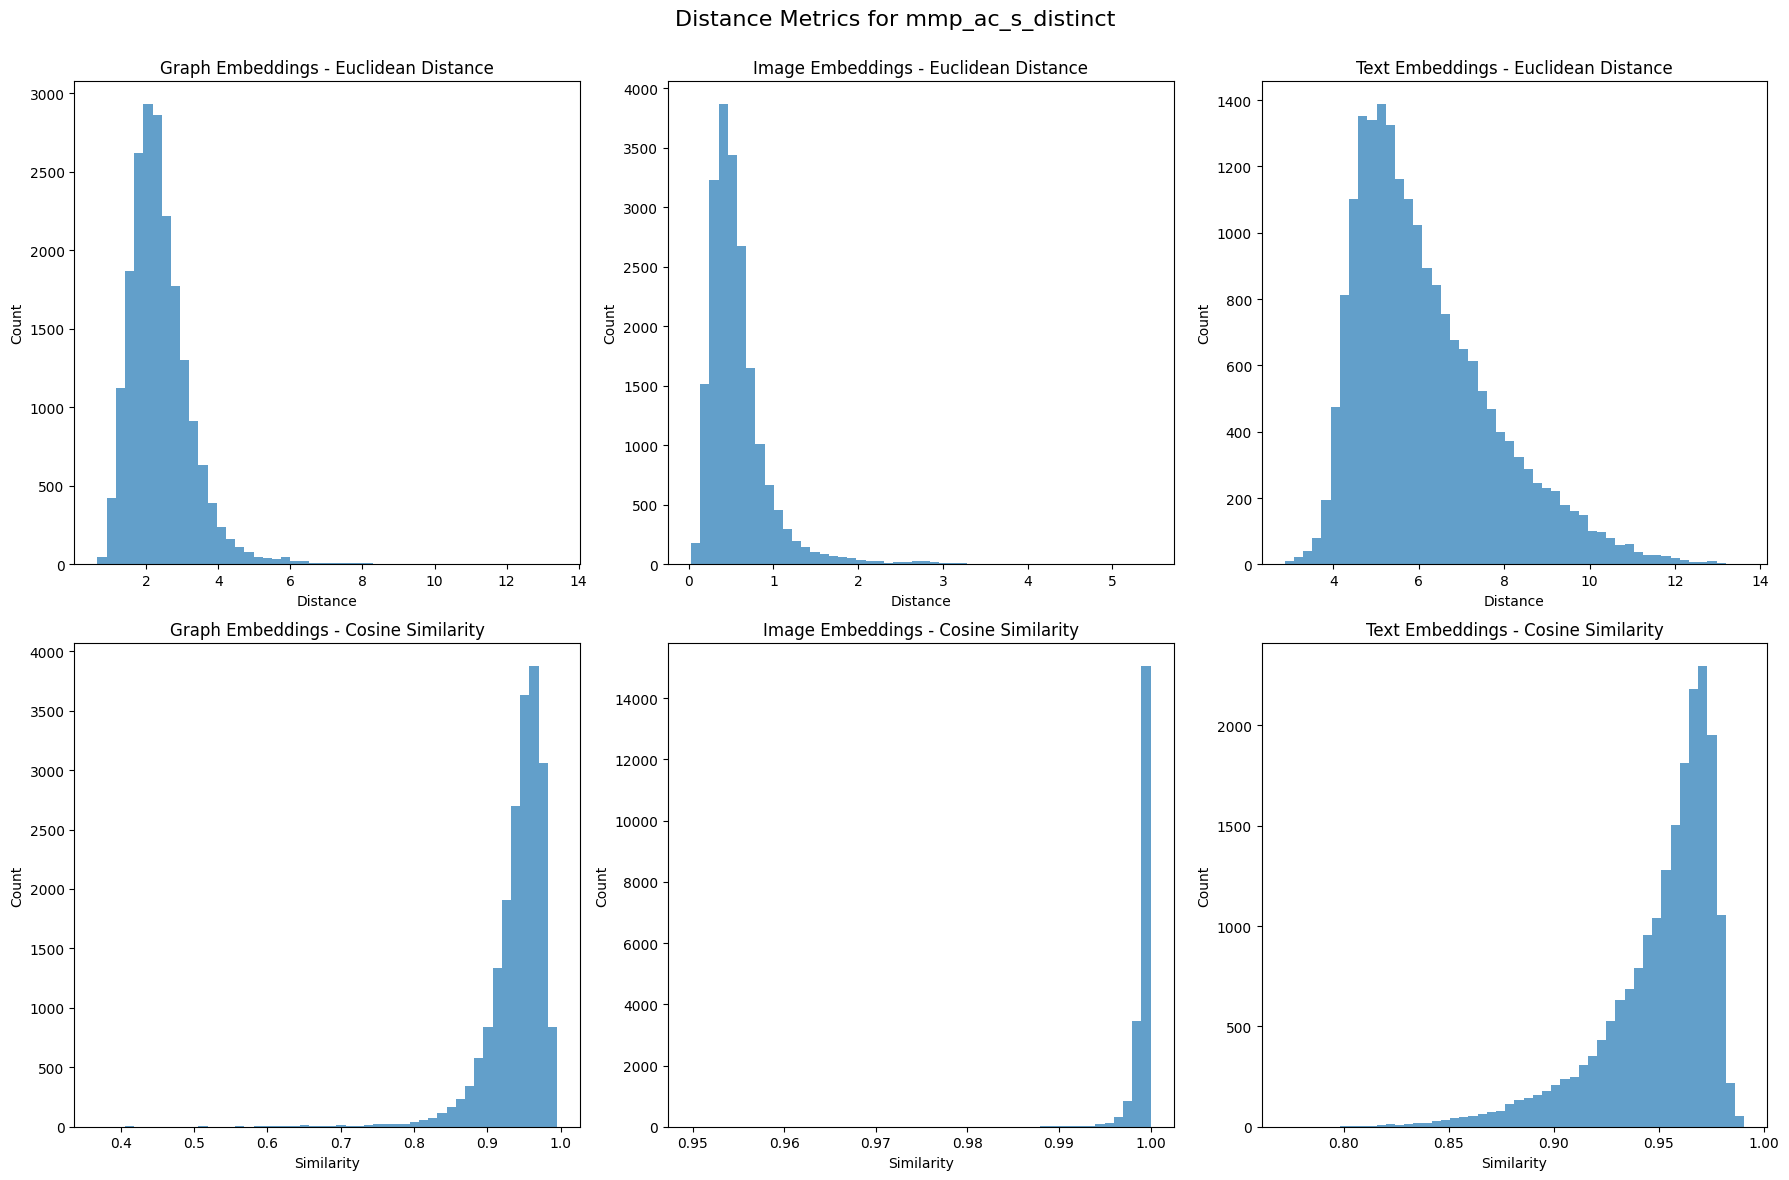

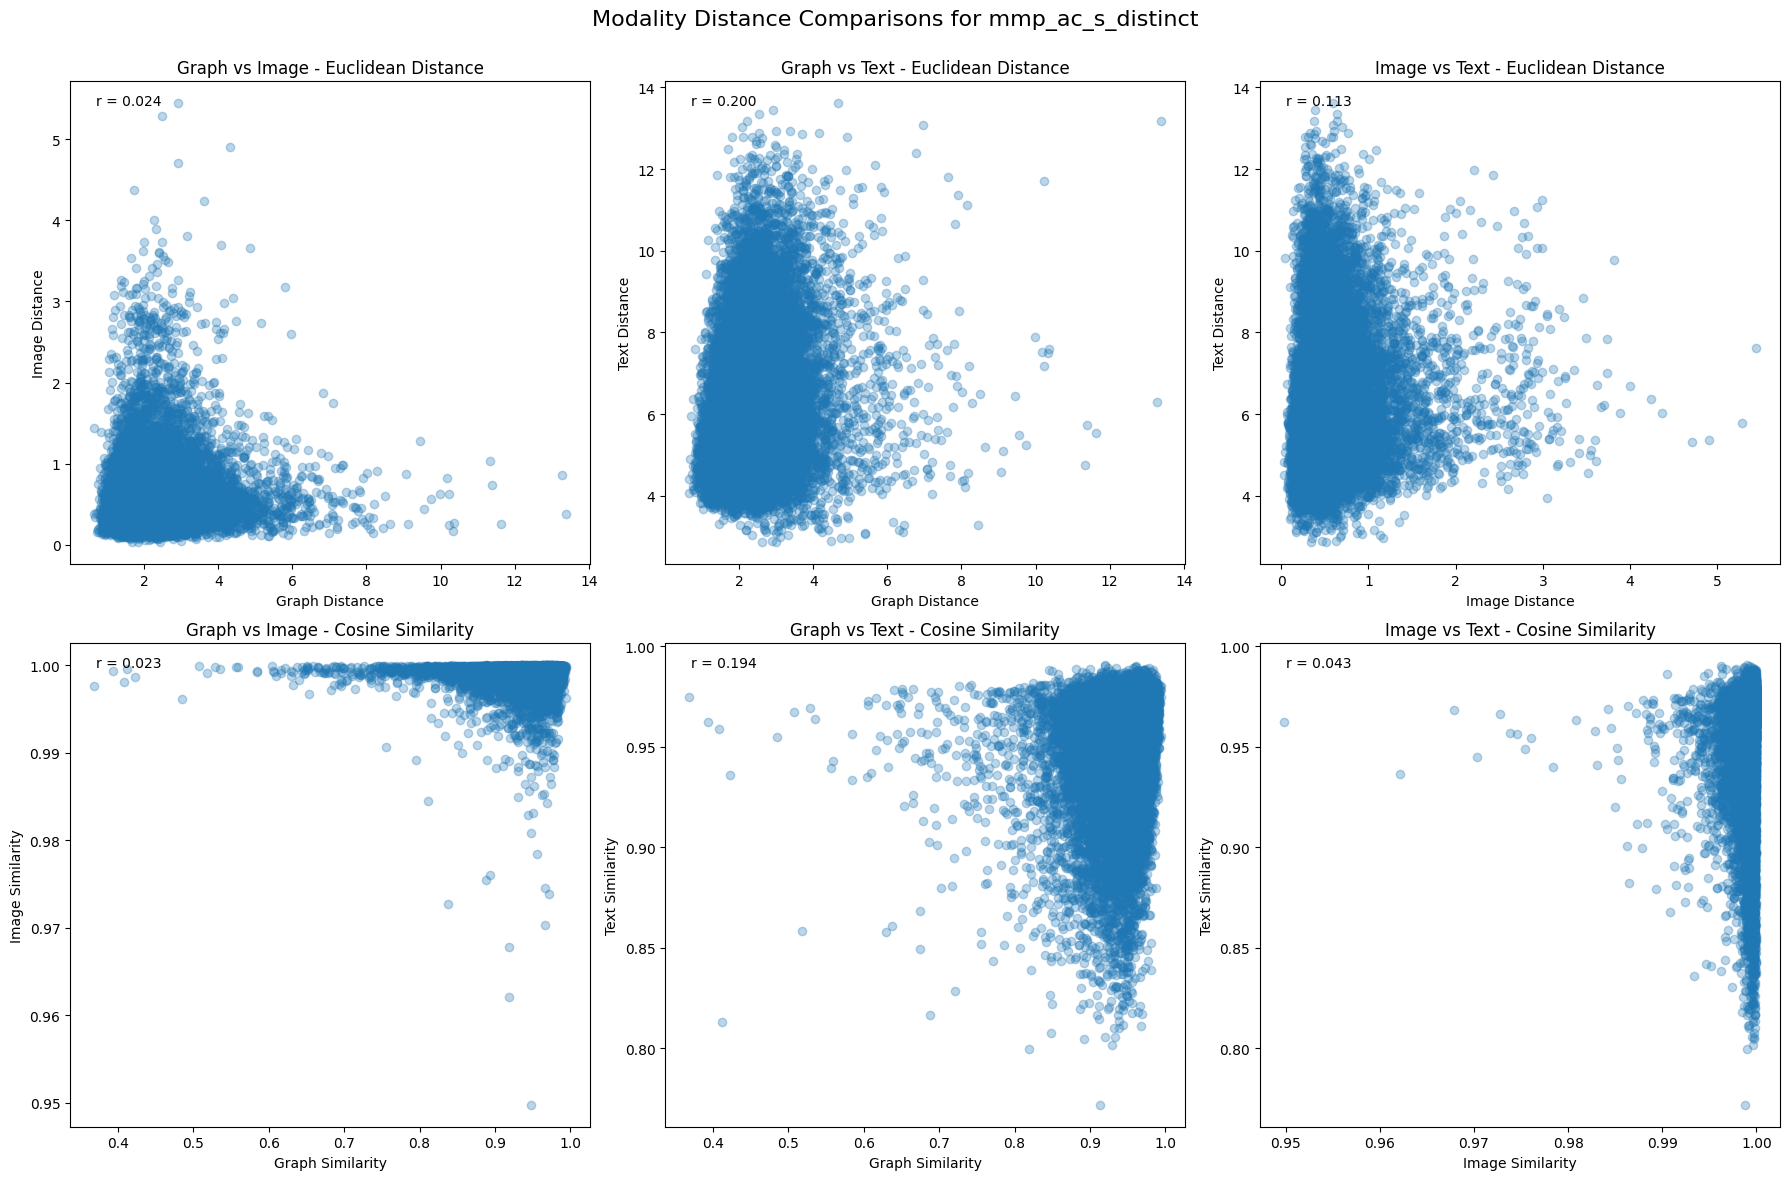


Analyzing dataset: mmp_ac_s_neg_distinct


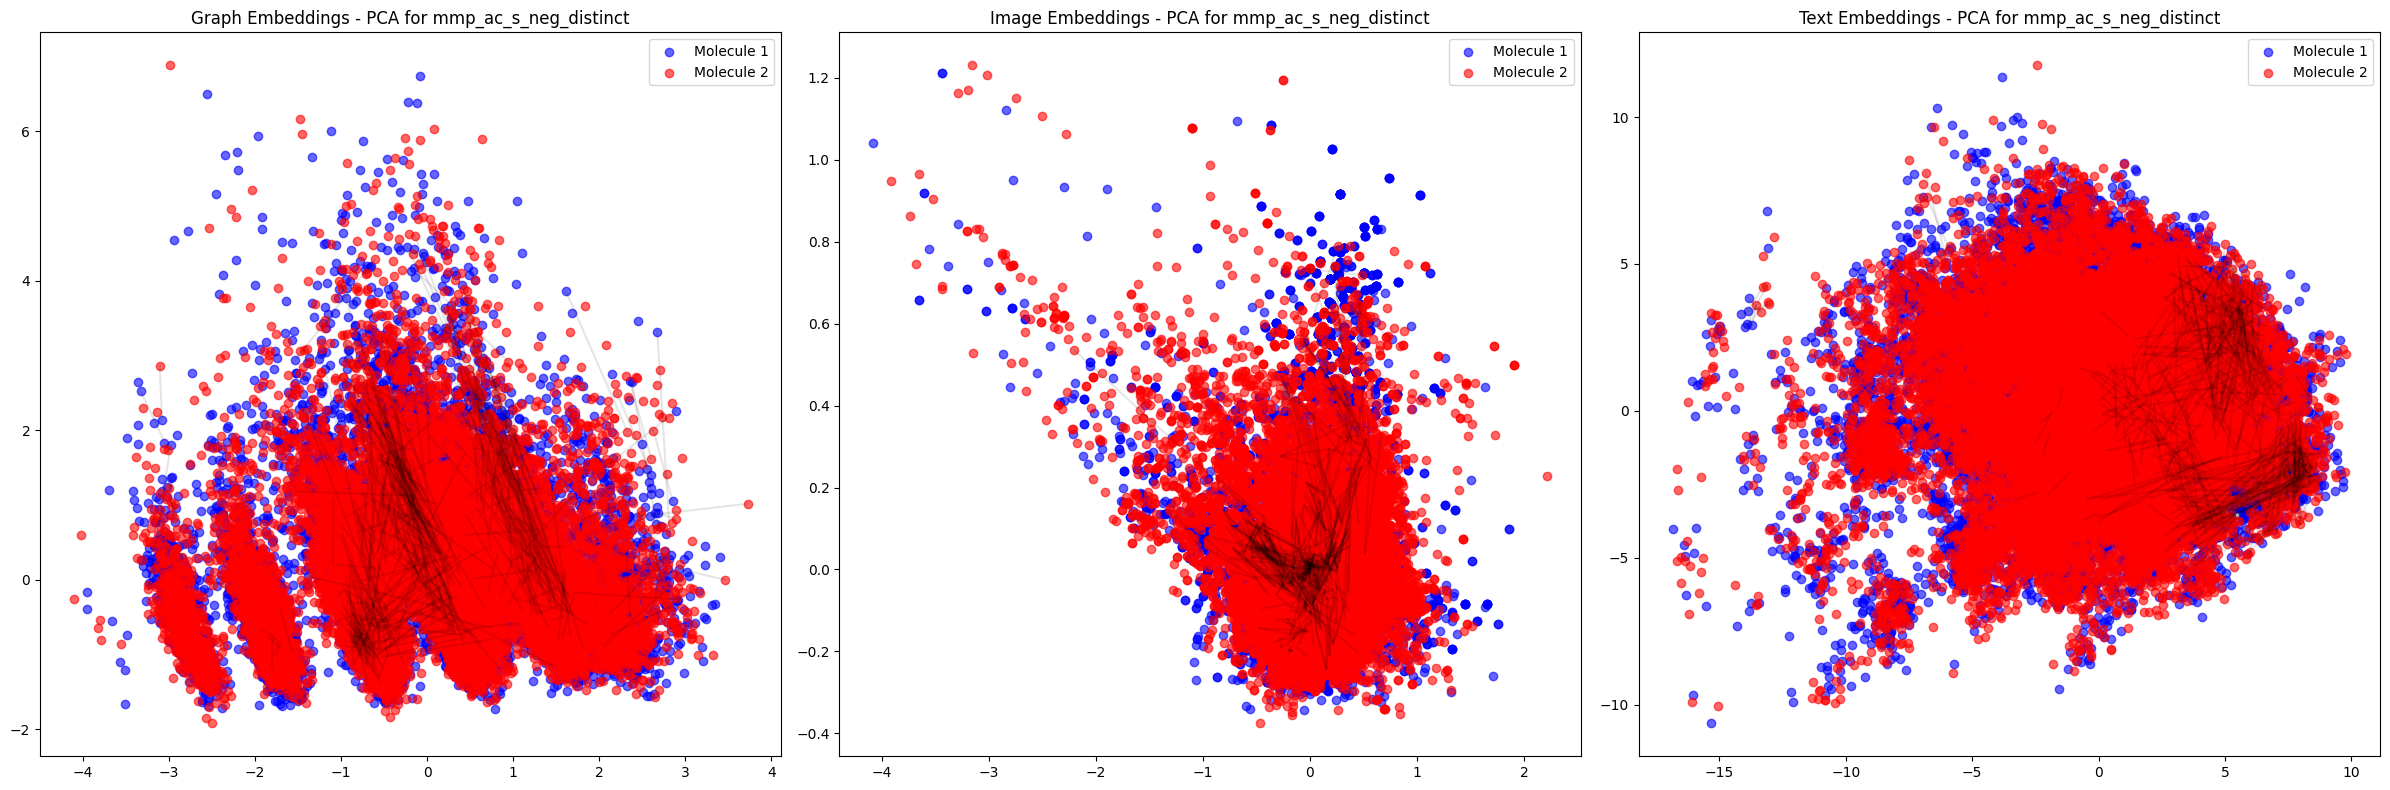

/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/umap/spectral.py:550: UserWarning: S

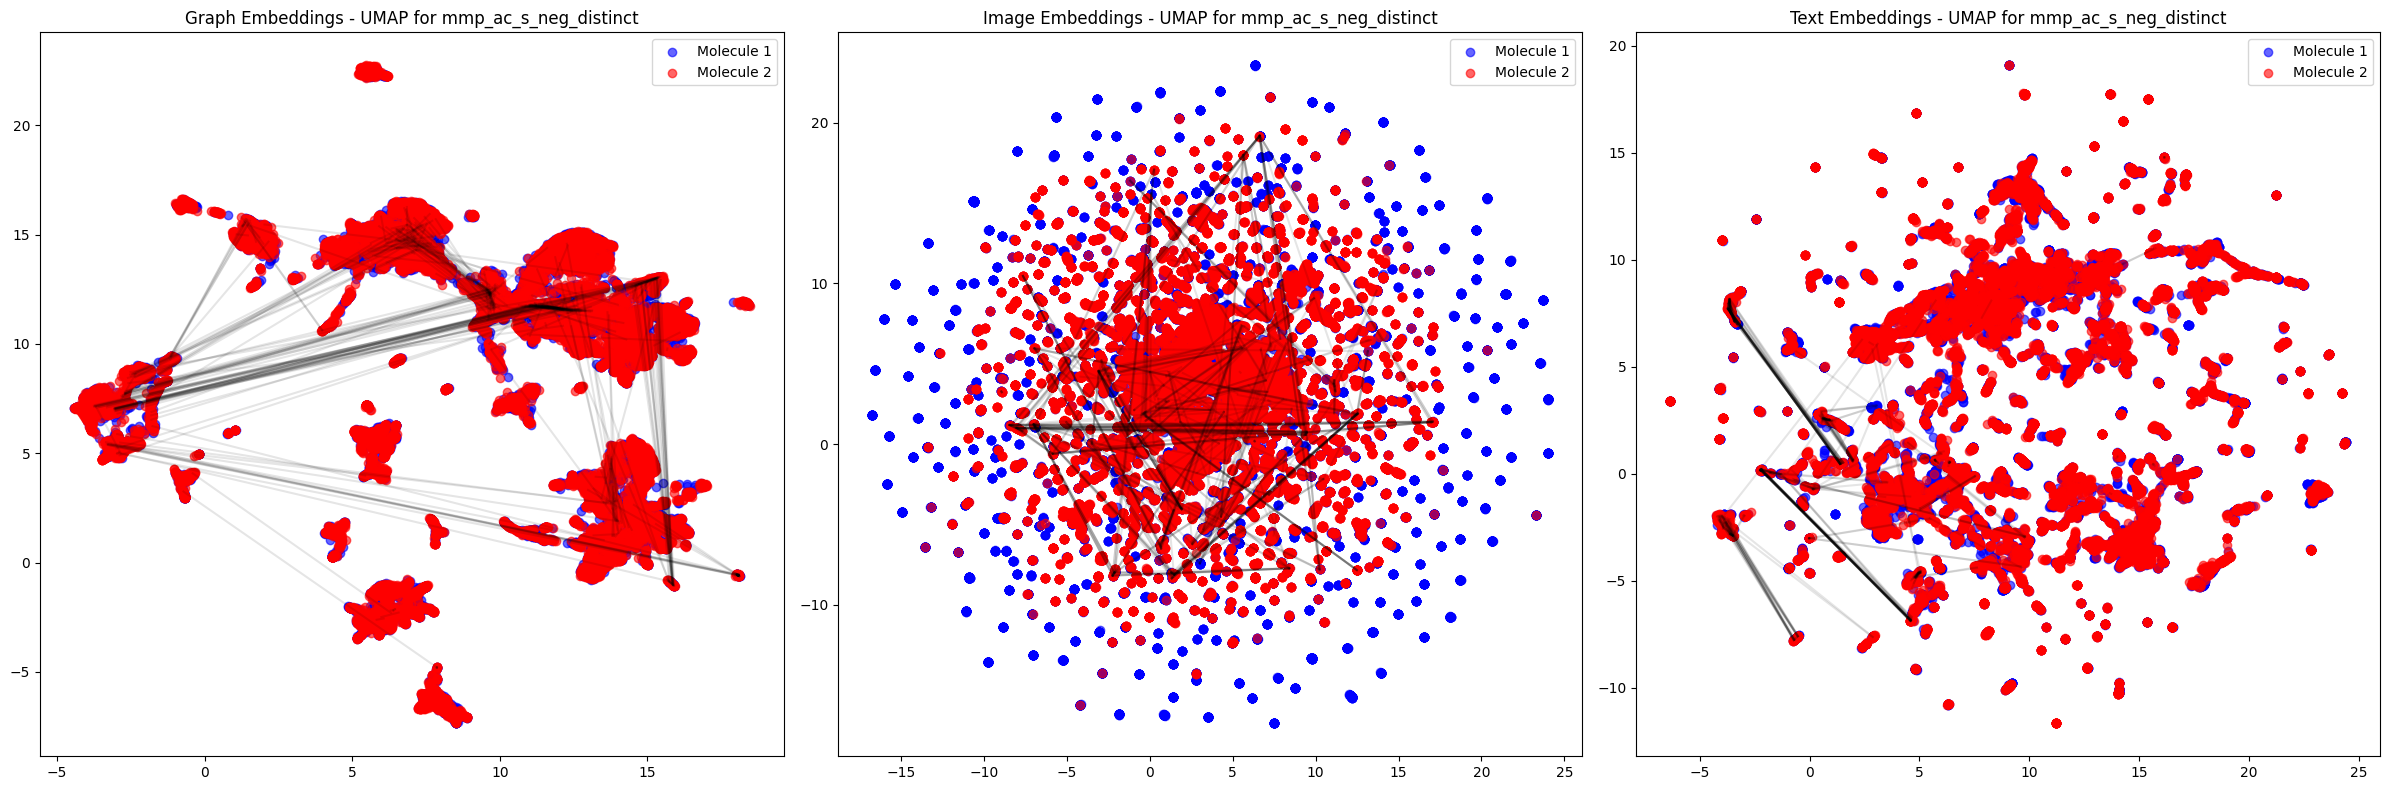

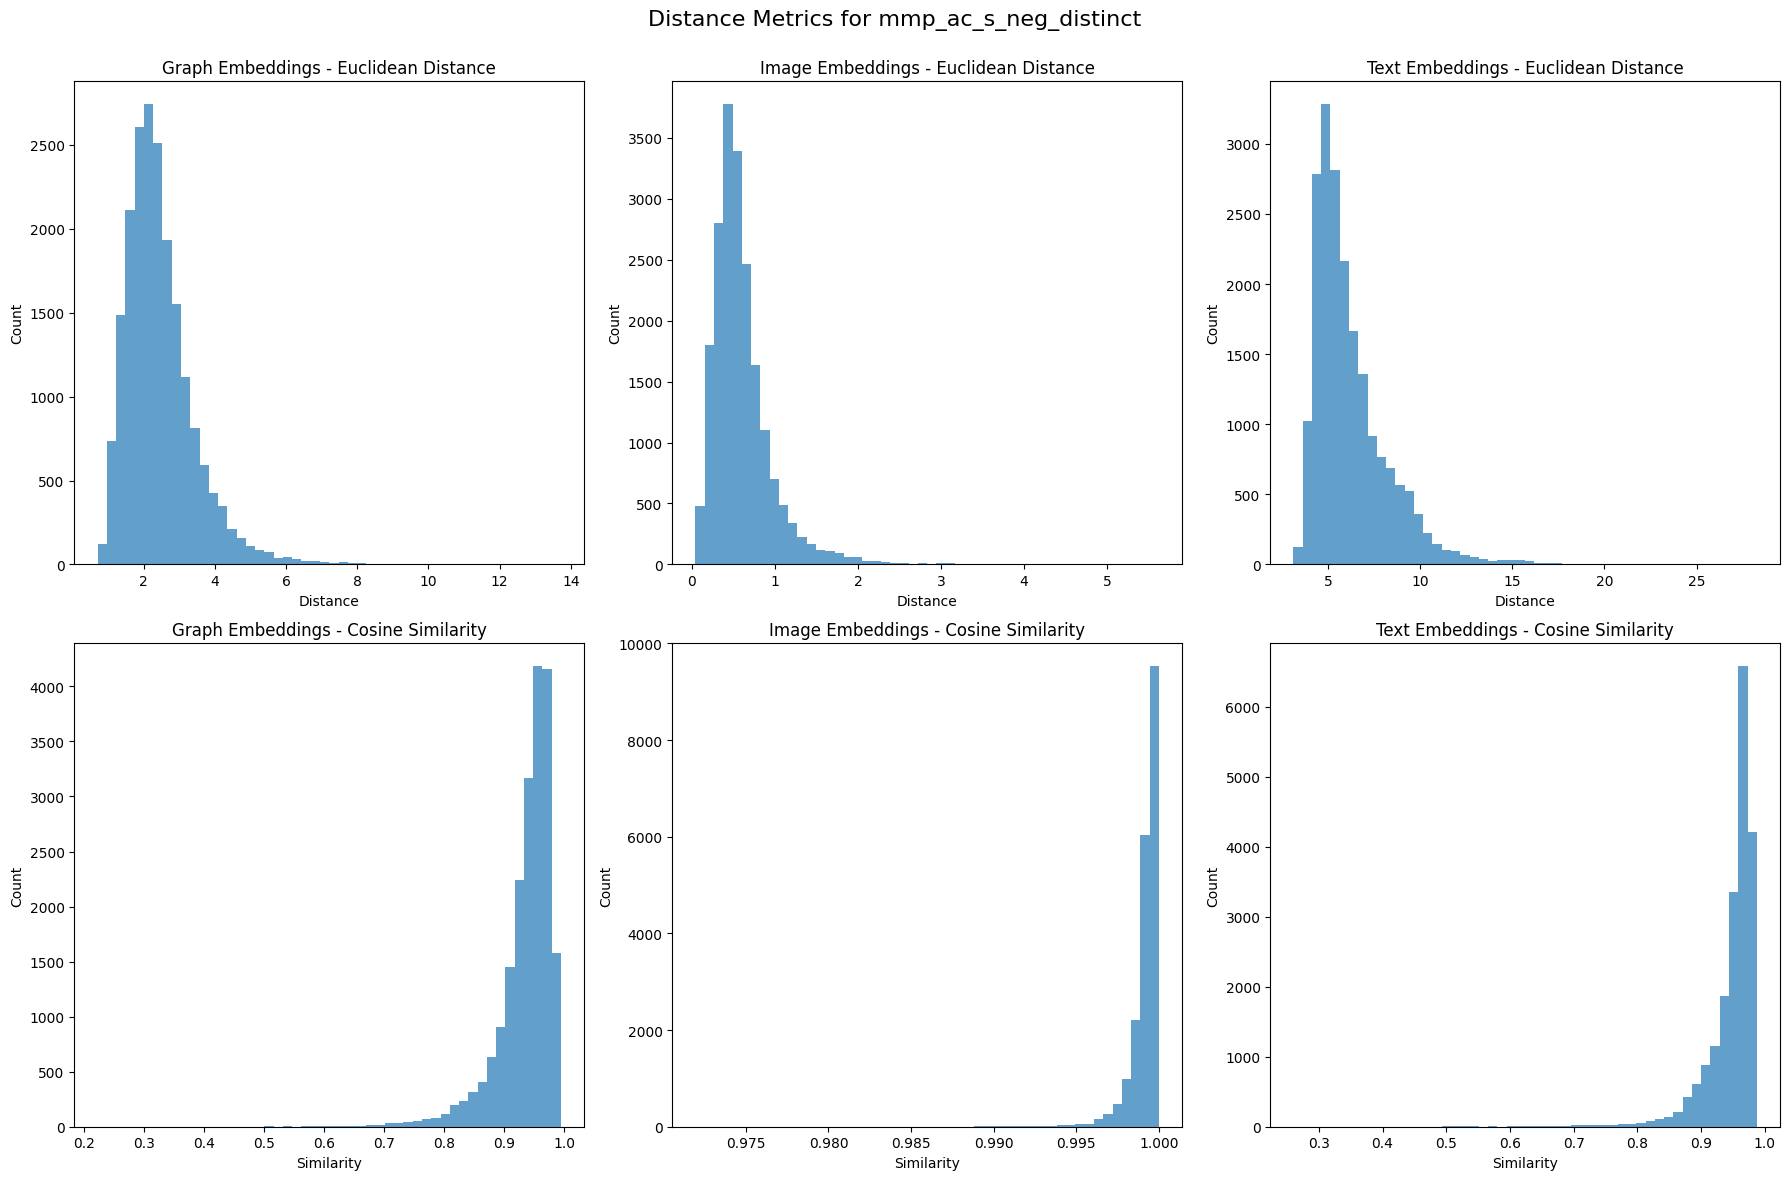

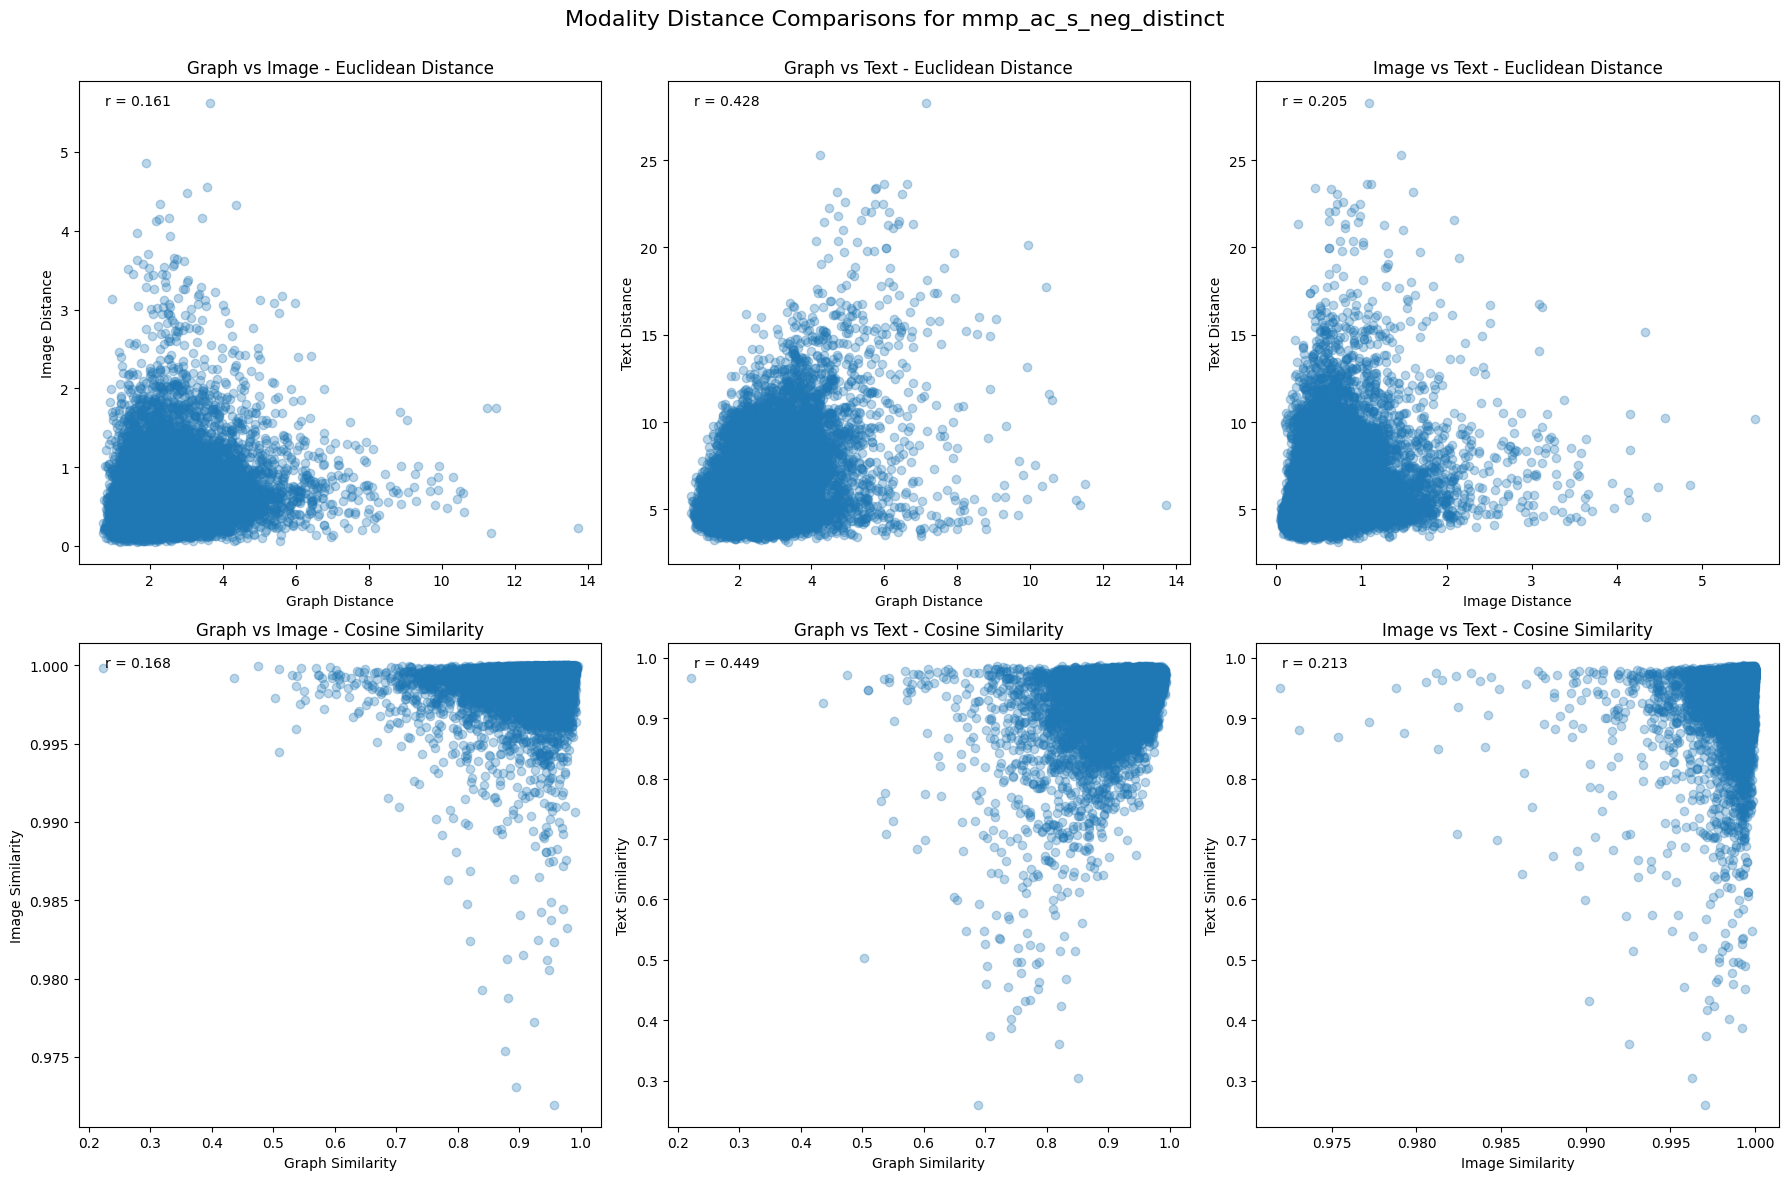

In [7]:
def visualize_mmp_embeddings(dataset_name, method='pca', cmap='viridis'):
    """
    Visualize matched molecular pairs embeddings with connection lines between pairs.
    
    Parameters:
        dataset_name (str): Name of the dataset (e.g., 'mmp_ac_s_distinct')
        method (str): Dimensionality reduction method ('pca' or 'umap')
        cmap (str): Colormap for visualization
    """
    # Load embeddings for both items in the pairs
    graph_embs_1 = np.load(f"graph_embeddings_{dataset_name}_item_1.npy")
    image_embs_1 = np.load(f"image_embeddings_{dataset_name}_item_1.npy")
    text_embs_1 = np.load(f"text_embeddings_{dataset_name}_item_1.npy")
    
    graph_embs_2 = np.load(f"graph_embeddings_{dataset_name}_item_2.npy")
    image_embs_2 = np.load(f"image_embeddings_{dataset_name}_item_2.npy")
    text_embs_2 = np.load(f"text_embeddings_{dataset_name}_item_2.npy")
    
    # Load the original data to get labels if needed
    df = pd.read_csv(f"{dataset_name}.csv")
    
    # Choose dimensionality reduction method
    if method.lower() == 'pca':
        reducer = PCA(n_components=2)
    elif method.lower() == 'umap':
        reducer = umap.UMAP(n_components=2, random_state=42)
    else:
        raise ValueError(f"Unknown reduction method: {method}")
    
    # Create a figure with 3 subplots for each modality
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    modality_names = ['Graph', 'Image', 'Text']
    embs_list = [(graph_embs_1, graph_embs_2), 
                 (image_embs_1, image_embs_2), 
                 (text_embs_1, text_embs_2)]
    
    # Process each modality
    for i, ((embs_1, embs_2), ax) in enumerate(zip(embs_list, axes)):
        # Combine embeddings for dimensionality reduction
        combined_embs = np.vstack([embs_1, embs_2])
        reduced_embs = reducer.fit_transform(combined_embs)
        
        # Split back into the two sets
        n = embs_1.shape[0]
        reduced_embs_1 = reduced_embs[:n]
        reduced_embs_2 = reduced_embs[n:]
        
        # Plot both sets of points
        ax.scatter(reduced_embs_1[:, 0], reduced_embs_1[:, 1], 
                   c='blue', alpha=0.6, label='Molecule 1')
        ax.scatter(reduced_embs_2[:, 0], reduced_embs_2[:, 1], 
                   c='red', alpha=0.6, label='Molecule 2')
        
        # Draw lines connecting matched pairs (plot a subset if there are too many)
        max_lines = min(500, n)  # Limit the number of lines to prevent overcrowding
        for j in range(max_lines):
            ax.plot([reduced_embs_1[j, 0], reduced_embs_2[j, 0]],
                    [reduced_embs_1[j, 1], reduced_embs_2[j, 1]], 'k-', alpha=0.1)
        
        ax.set_title(f'{modality_names[i]} Embeddings - {method.upper()} for {dataset_name}')
        ax.legend()
    
    plt.tight_layout()
    plt.show()


def calculate_pair_distances(dataset_name):
    """
    Calculate euclidean distances and cosine similarities between matched molecular pairs.
    
    Parameters:
        dataset_name (str): Name of the dataset (e.g., 'mmp_ac_s_distinct')
        
    Returns:
        dict: Dictionary containing distance metrics for each modality
    """
    # Load embeddings for both items in the pairs
    graph_embs_1 = np.load(f"graph_embeddings_{dataset_name}_item_1.npy")
    image_embs_1 = np.load(f"image_embeddings_{dataset_name}_item_1.npy")
    text_embs_1 = np.load(f"text_embeddings_{dataset_name}_item_1.npy")
    
    graph_embs_2 = np.load(f"graph_embeddings_{dataset_name}_item_2.npy")
    image_embs_2 = np.load(f"image_embeddings_{dataset_name}_item_2.npy")
    text_embs_2 = np.load(f"text_embeddings_{dataset_name}_item_2.npy")

    def clip_to_min(embs1, embs2):
        n = min(embs1.shape[0], embs2.shape[0])
        return embs1[:n], embs2[:n]
    
    graph_embs_1, graph_embs_2 = clip_to_min(graph_embs_1, graph_embs_2)
    image_embs_1, image_embs_2 = clip_to_min(image_embs_1, image_embs_2)
    text_embs_1, text_embs_2   = clip_to_min(text_embs_1, text_embs_2)
    
    # Calculate euclidean distances
    graph_euclidean = np.sqrt(np.sum((graph_embs_1 - graph_embs_2)**2, axis=1))
    image_euclidean = np.sqrt(np.sum((image_embs_1 - image_embs_2)**2, axis=1))
    text_euclidean = np.sqrt(np.sum((text_embs_1 - text_embs_2)**2, axis=1))
    
    # Calculate cosine similarities
    def cosine_sim(a, b):
        return np.sum(a * b, axis=1) / (np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1))
    
    graph_cosine = cosine_sim(graph_embs_1, graph_embs_2)
    image_cosine = cosine_sim(image_embs_1, image_embs_2)
    text_cosine = cosine_sim(text_embs_1, text_embs_2)
    
    return {
        'graph_euclidean': graph_euclidean,
        'image_euclidean': image_euclidean,
        'text_euclidean': text_euclidean,
        'graph_cosine': graph_cosine,
        'image_cosine': image_cosine,
        'text_cosine': text_cosine
    }


def plot_distance_distributions(dataset_name):
    """
    Plot distributions of euclidean distances and cosine similarities for matched pairs.
    
    Parameters:
        dataset_name (str): Name of the dataset (e.g., 'mmp_ac_s_distinct')
    """
    distances = calculate_pair_distances(dataset_name)
    
    # Create figure with 2 rows (euclidean, cosine) and 3 columns (modalities)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Plot euclidean distances
    axes[0, 0].hist(distances['graph_euclidean'], bins=50, alpha=0.7)
    axes[0, 0].set_title('Graph Embeddings - Euclidean Distance')
    axes[0, 0].set_xlabel('Distance')
    axes[0, 0].set_ylabel('Count')
    
    axes[0, 1].hist(distances['image_euclidean'], bins=50, alpha=0.7)
    axes[0, 1].set_title('Image Embeddings - Euclidean Distance')
    axes[0, 1].set_xlabel('Distance')
    axes[0, 1].set_ylabel('Count')
    
    axes[0, 2].hist(distances['text_euclidean'], bins=50, alpha=0.7)
    axes[0, 2].set_title('Text Embeddings - Euclidean Distance')
    axes[0, 2].set_xlabel('Distance')
    axes[0, 2].set_ylabel('Count')
    
    # Plot cosine similarities
    axes[1, 0].hist(distances['graph_cosine'], bins=50, alpha=0.7)
    axes[1, 0].set_title('Graph Embeddings - Cosine Similarity')
    axes[1, 0].set_xlabel('Similarity')
    axes[1, 0].set_ylabel('Count')
    
    axes[1, 1].hist(distances['image_cosine'], bins=50, alpha=0.7)
    axes[1, 1].set_title('Image Embeddings - Cosine Similarity')
    axes[1, 1].set_xlabel('Similarity')
    axes[1, 1].set_ylabel('Count')
    
    axes[1, 2].hist(distances['text_cosine'], bins=50, alpha=0.7)
    axes[1, 2].set_title('Text Embeddings - Cosine Similarity')
    axes[1, 2].set_xlabel('Similarity')
    axes[1, 2].set_ylabel('Count')
    
    plt.suptitle(f'Distance Metrics for {dataset_name}', fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


def plot_modality_distance_comparison(dataset_name):
    """
    Create scatter plots comparing distances across modalities.
    
    Parameters:
        dataset_name (str): Name of the dataset (e.g., 'mmp_ac_s_distinct')
    """
    distances = calculate_pair_distances(dataset_name)
    
    # Create figure with 2 rows (euclidean, cosine) and 3 columns (modality comparisons)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Euclidean distance comparisons
    axes[0, 0].scatter(distances['graph_euclidean'], distances['image_euclidean'], alpha=0.3)
    axes[0, 0].set_title('Graph vs Image - Euclidean Distance')
    axes[0, 0].set_xlabel('Graph Distance')
    axes[0, 0].set_ylabel('Image Distance')
    
    axes[0, 1].scatter(distances['graph_euclidean'], distances['text_euclidean'], alpha=0.3)
    axes[0, 1].set_title('Graph vs Text - Euclidean Distance')
    axes[0, 1].set_xlabel('Graph Distance')
    axes[0, 1].set_ylabel('Text Distance')
    
    axes[0, 2].scatter(distances['image_euclidean'], distances['text_euclidean'], alpha=0.3)
    axes[0, 2].set_title('Image vs Text - Euclidean Distance')
    axes[0, 2].set_xlabel('Image Distance')
    axes[0, 2].set_ylabel('Text Distance')
    
    # Cosine similarity comparisons
    axes[1, 0].scatter(distances['graph_cosine'], distances['image_cosine'], alpha=0.3)
    axes[1, 0].set_title('Graph vs Image - Cosine Similarity')
    axes[1, 0].set_xlabel('Graph Similarity')
    axes[1, 0].set_ylabel('Image Similarity')
    
    axes[1, 1].scatter(distances['graph_cosine'], distances['text_cosine'], alpha=0.3)
    axes[1, 1].set_title('Graph vs Text - Cosine Similarity')
    axes[1, 1].set_xlabel('Graph Similarity')
    axes[1, 1].set_ylabel('Text Similarity')
    
    axes[1, 2].scatter(distances['image_cosine'], distances['text_cosine'], alpha=0.3)
    axes[1, 2].set_title('Image vs Text - Cosine Similarity')
    axes[1, 2].set_xlabel('Image Similarity')
    axes[1, 2].set_ylabel('Text Similarity')
    
    # Calculate and display correlation coefficients
    for i in range(2):
        for j in range(3):
            if i == 0:  # Euclidean
                if j == 0:
                    corr = np.corrcoef(distances['graph_euclidean'], distances['image_euclidean'])[0, 1]
                elif j == 1:
                    corr = np.corrcoef(distances['graph_euclidean'], distances['text_euclidean'])[0, 1]
                else:
                    corr = np.corrcoef(distances['image_euclidean'], distances['text_euclidean'])[0, 1]
            else:  # Cosine
                if j == 0:
                    corr = np.corrcoef(distances['graph_cosine'], distances['image_cosine'])[0, 1]
                elif j == 1:
                    corr = np.corrcoef(distances['graph_cosine'], distances['text_cosine'])[0, 1]
                else:
                    corr = np.corrcoef(distances['image_cosine'], distances['text_cosine'])[0, 1]
            
            axes[i, j].annotate(f"r = {corr:.3f}", xy=(0.05, 0.95), xycoords='axes fraction')
    
    plt.suptitle(f'Modality Distance Comparisons for {dataset_name}', fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


# Example usage
for dataset in ['mmp_ac_s_distinct', 'mmp_ac_s_neg_distinct']:
    print(f"\nAnalyzing dataset: {dataset}")
    
    # Visualize embeddings with PCA
    visualize_mmp_embeddings(dataset, method='pca')
    
    # Visualize embeddings with UMAP
    visualize_mmp_embeddings(dataset, method='umap')
    
    # Plot distance distributions
    plot_distance_distributions(dataset)
    
    # Compare distances across modalities
    plot_modality_distance_comparison(dataset)


Comparing positive and negative pairs:
Absolute difference for graph_euclidean: 0.0741
Absolute difference for image_euclidean: 0.0267
Absolute difference for text_euclidean: 0.0456
Absolute difference for graph_cosine: 0.0055
Absolute difference for image_cosine: 0.0000
Absolute difference for text_cosine: 0.0034


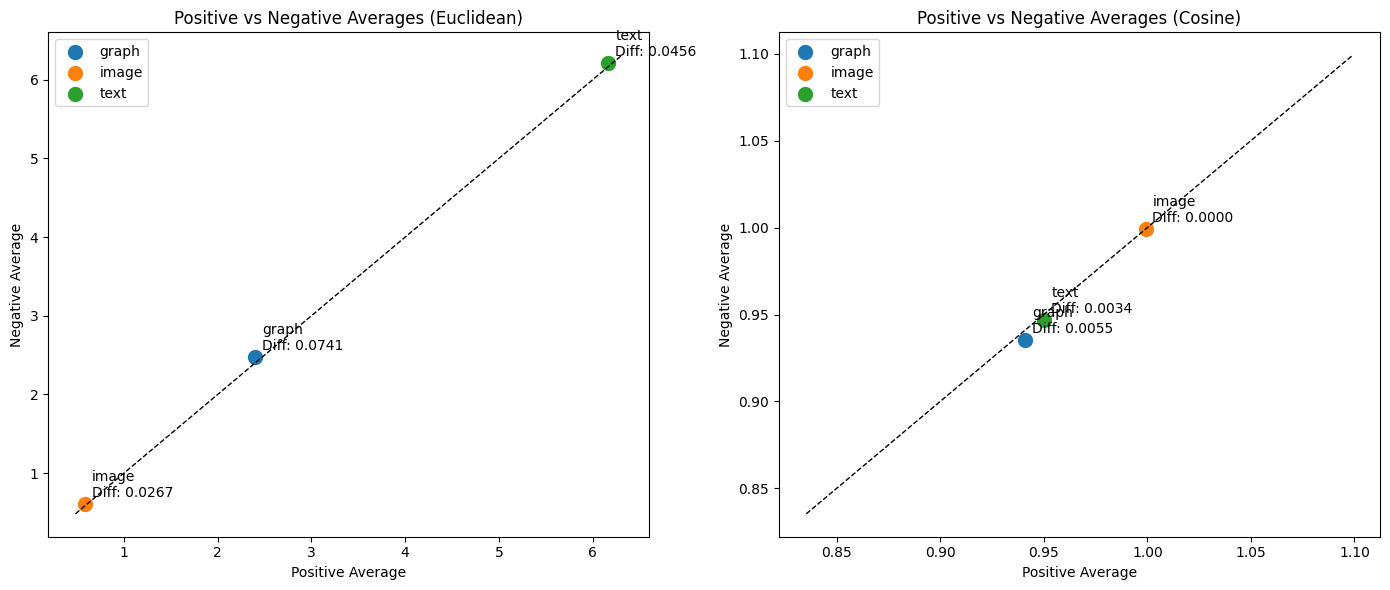

In [8]:
def compute_average_distances(dataset_name):
    """
    Compute the average Euclidean distance and cosine similarity for each modality.
    
    Parameters:
        dataset_name (str): Name of the dataset.
        
    Returns:
        dict: Dictionary with average values for each distance metric.
    """
    distances = calculate_pair_distances(dataset_name)
    avg_distances = {}
    for key, vals in distances.items():
        avg_distances[key] = np.mean(vals)
    return avg_distances


def compare_positive_negative_averages(pos_dataset, neg_dataset):
    """
    Compute and print the absolute differences in average distances between positive and negative pairs.
    
    Parameters:
        pos_dataset (str): Dataset name for positive pairs.
        neg_dataset (str): Dataset name for negative pairs.
        
    Returns:
        tuple: (pos_avgs, neg_avgs, abs_diff) dictionaries for positive averages, negative averages, 
               and absolute differences, respectively.
    """
    pos_avgs = compute_average_distances(pos_dataset)
    neg_avgs = compute_average_distances(neg_dataset)
    
    abs_diff = {}
    for key in pos_avgs:
        abs_diff[key] = abs(pos_avgs[key] - neg_avgs[key])
        print(f"Absolute difference for {key}: {abs_diff[key]:.4f}")
    
    return pos_avgs, neg_avgs, abs_diff


def plot_positive_vs_negative_scatter(pos_dataset, neg_dataset):
    """
    Create scatter plots comparing the average distances between positive and negative pairs.
    
    For each metric (Euclidean and cosine) the positive averages are plotted against the negative averages 
    for each modality. Each point is annotated with the modality and the absolute difference.
    
    Parameters:
        pos_dataset (str): Dataset name for positive pairs.
        neg_dataset (str): Dataset name for negative pairs.
    """
    pos_avgs, neg_avgs, abs_diff = compare_positive_negative_averages(pos_dataset, neg_dataset)
    
    modalities = ['graph', 'image', 'text']
    metrics = ['euclidean', 'cosine']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for i, metric in enumerate(metrics):
        for modality in modalities:
            key = f"{modality}_{metric}"
            axes[i].scatter(pos_avgs[key], neg_avgs[key], label=modality, s=100)
            axes[i].annotate(f"{modality}\nDiff: {abs_diff[key]:.4f}",
                             (pos_avgs[key], neg_avgs[key]),
                             textcoords="offset points", xytext=(5,5))
        # Plot the line y = x for reference
        all_pos = [pos_avgs[f"{m}_{metric}"] for m in modalities]
        all_neg = [neg_avgs[f"{m}_{metric}"] for m in modalities]
        min_val = min(min(all_pos), min(all_neg)) - 0.1
        max_val = max(max(all_pos), max(all_neg)) + 0.1
        axes[i].plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)
        axes[i].set_xlabel("Positive Average")
        axes[i].set_ylabel("Negative Average")
        axes[i].set_title(f"Positive vs Negative Averages ({metric.capitalize()})")
        axes[i].legend()
    
    plt.tight_layout()
    plt.show()

print("\nComparing positive and negative pairs:")
plot_positive_vs_negative_scatter('mmp_ac_s_distinct', 'mmp_ac_s_neg_distinct')

In [ ]:
def visualize_embeddings_separately(dataset_names, method='pca', cmap='viridis', colorbar_label='Label'):
    """
    Visualize the graph, image, and text embeddings using PCA or UMAP,
    and color the points by the provided label values using a sequential colormap.

    Parameters:
        graph_embs (ndarray): Graph modality embeddings.
        image_embs (ndarray): Image modality embeddings.
        text_embs (ndarray): Text modality embeddings.
        labels (list or array): Numeric labels (e.g., floating numbers) corresponding to each data point.
        method (str): 'pca' or 'umap' to choose the dimensionality reduction method.
        cmap (str): Colormap to use for coloring the points.
        colorbar_label (str): Label for the colorbar.

    Returns:
        None
    """
    # Ensure labels are in a numpy array
    for dataset_name in dataset_names:
        df = pd.read_csv(f"/Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/data_root/datasets/raw_data/MoleculeNet/{dataset_name.lower()}.csv")
        labels_col_item_1 = df.columns[1]
        smiles_dict[dataset_name + '_labels_1'] = df[labels_col_item_1].tolist()
        labels = smiles_dict[dataset_name + '_labels_1']
        labels_col_item_2 = df.columns[3]
        smiles_dict[dataset_name + '_labels_2'] = df[labels_col_item_2].tolist()
        labels = smiles_dict[dataset_name + '_labels_2']

        graph_embs_1 = np.load(f"/Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/notebooks/graph_embeddings_{dataset_name.lower()}_item_1.npy")
        image_embs_1 = np.load(f'/Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/notebooks/image_embeddings_{dataset_name.lower()}_item_1.npy')
        text_embs_1 = np.load(f'/Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/notebooks/text_embeddings_{dataset_name.lower()}_item_1.npy')
        graph_embs_2 = np.load(f"/Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/notebooks/graph_embeddings_{dataset_name.lower()}_item_2.npy")
        image_embs_2 = np.load(f'/Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/notebooks/image_embeddings_{dataset_name.lower()}_item_2.npy')
        text_embs_2 = np.load(f'/Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/notebooks/text_embeddings_{dataset_name.lower()}_item_2.npy')  
    
        def reduce_embeddings(embs):
            if method.lower() == 'pca':
                reducer = PCA(n_components=2)
            elif method.lower() == 'umap':
                reducer = umap.UMAP(n_components=2, random_state=42)
            else:
                raise ValueError(f"Unknown reduction method: {method}")
            return reducer.fit_transform(embs)
        
        # Create a figure with 3 subplots for each modality
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
        
        # Visualize Graph embeddings
        reduced_graph = reduce_embeddings(graph_embs_1)
        scatter1 = ax1.scatter(reduced_graph[:, 0], reduced_graph[:, 1],
                            c=labels, cmap=cmap, alpha=0.6)
        ax1.set_title(f'{method.upper()} visualization of Graph embeddings: {dataset_name}')
        fig.colorbar(scatter1, ax=ax1, label=colorbar_label)
        
        # Visualize Image embeddings
        reduced_image = reduce_embeddings(image_embs)
        scatter2 = ax2.scatter(reduced_image[:, 0], reduced_image[:, 1],
                            c=labels, cmap=cmap, alpha=0.6)
        ax2.set_title(f'{method.upper()} visualization of Image embeddings: {dataset_name}')
        fig.colorbar(scatter2, ax=ax2, label=colorbar_label)
        
        # Visualize Text embeddings
        reduced_text = reduce_embeddings(text_embs)
        scatter3 = ax3.scatter(reduced_text[:, 0], reduced_text[:, 1],
                            c=labels, cmap=cmap, alpha=0.6)
        ax3.set_title(f'{method.upper()} visualization of Text embeddings: {dataset_name}')
        fig.colorbar(scatter3, ax=ax3, label=colorbar_label)
        
        plt.tight_layout()
        plt.show()


esol = ['ESOL']
lipo = ['LIPOPHILICITY']

visualize_embeddings_separately(esol, method='pca', cmap='winter', colorbar_label='Solubility')
visualize_embeddings_separately(lipo, method='pca', cmap='viridis', colorbar_label='Lipophilicity')
visualize_embeddings_separately(esol, method='umap', cmap='winter', colorbar_label='Solubility')
visualize_embeddings_separately(lipo, method='umap', cmap='viridis', colorbar_label='Lipophilicity')